In [13]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [20]:
# Optimized LLM Interface with Caching and Solution Generation
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import json
import requests
from typing import Dict, List, Tuple, Optional
import hashlib
import pickle
from pathlib import Path

print("=== OPTIMIZED LLM INTERFACE WITH CACHING ===")

class OptimizedLLMInterface:
    """Optimized LLM interface with caching, solution generation, and minimal overhead"""
    
    def __init__(self, model_path="llama3:latest", cache_dir="./llm_cache"):
        self.model_path = model_path
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)
        self.connection_status = None
        self.solution_cache = {}
        self.param_cache = {}
        self._verify_connection()
        self._load_cache()
        
    def _verify_connection(self):
        """Verify if LLaMA-3 is accessible"""
        try:
            response = requests.get('http://localhost:11434/api/tags', timeout=2)
            if response.status_code == 200:
                models = response.json().get('models', [])
                model_names = [model['name'] for model in models]
                
                if self.model_path in model_names:
                    self.connection_status = "ollama_connected"
                    print(f"✅ Ollama connected with {self.model_path}")
                    return True
                else:
                    self.connection_status = "ollama_no_model"
            else:
                self.connection_status = "ollama_failed"
        except Exception:
            self.connection_status = "ollama_unavailable"
        
        return False
    
    def _load_cache(self):
        """Load existing cache from disk"""
        try:
            # Load solution cache
            solution_cache_file = self.cache_dir / "solution_cache.pkl"
            if solution_cache_file.exists():
                with open(solution_cache_file, 'rb') as f:
                    self.solution_cache = pickle.load(f)
                print(f"✅ Loaded {len(self.solution_cache)} cached solutions")
            
            # Load parameter cache
            param_cache_file = self.cache_dir / "param_cache.pkl"
            if param_cache_file.exists():
                with open(param_cache_file, 'rb') as f:
                    self.param_cache = pickle.load(f)
                print(f"✅ Loaded {len(self.param_cache)} cached parameters")
        except Exception as e:
            print(f"⚠️ Could not load cache: {e}")
    
    def _save_cache(self):
        """Save cache to disk"""
        try:
            # Save solution cache
            solution_cache_file = self.cache_dir / "solution_cache.pkl"
            with open(solution_cache_file, 'wb') as f:
                pickle.dump(self.solution_cache, f)
            
            # Save parameter cache
            param_cache_file = self.cache_dir / "param_cache.pkl"
            with open(param_cache_file, 'wb') as f:
                pickle.dump(self.param_cache, f)
        except Exception as e:
            print(f"⚠️ Could not save cache: {e}")
    
    def _get_cache_key(self, data):
        """Generate a cache key from data"""
        data_str = json.dumps(data, sort_keys=True)
        return hashlib.md5(data_str.encode()).hexdigest()
    
    def _call_ollama(self, prompt, timeout=10):
        """Call local Ollama API for LLaMA-3 with timeout"""
        try:
            response = requests.post(
                'http://localhost:11434/api/generate',
                json={
                    'model': self.model_path,
                    'prompt': prompt,
                    'stream': False,
                    'options': {
                        'temperature': 0.7,
                        'num_predict': 500,
                        'timeout': timeout
                    }
                },
                timeout=timeout
            )
            if response.status_code == 200:
                return response.json()['response']
            else:
                return None
        except Exception:
            return None
    ######
    def generate_initial_solutions(self, instance_features, num_solutions=5):
        """Generate diverse initial solutions using LLM with better prompts"""
        cache_key = self._get_cache_key({
            'type': 'solutions',
            'features': instance_features,
            'num_solutions': num_solutions
        })
        
        # Check cache first
        if cache_key in self.solution_cache:
            print(f"✅ Using cached solutions for {instance_features['signature']}")
            return self.solution_cache[cache_key]
        
        if self.connection_status != "ollama_connected":
            # Fallback to rule-based approach
            return self._generate_rule_based_solutions(instance_features, num_solutions)
        
        # Create a more detailed prompt for solution generation
        prompt = f"""
Generate {num_solutions} diverse and high-quality initial solutions for a multi-objective knapsack problem.

Problem Details:
- Number of items: {instance_features['n_items']}
- Number of objectives: {instance_features['n_objectives']}
- Instance size: {instance_features['instance_size']}
- Capacity tightness: {instance_features['capacity_tightness']}

CRITICAL REQUIREMENTS:
1. Each solution MUST respect ALL capacity constraints for ALL objectives
2. Solutions should be diverse in terms of:
   - Number of items selected (vary from sparse to dense)
   - Distribution across different objective values
   - Exploration of different regions of the solution space
3. For maximization problems, prioritize items with high profit-to-weight ratios
4. For tight capacity constraints, be more selective in item selection

EXAMPLE FORMAT:
For a 10-item problem with 2 objectives, a good solution might be:
[2, 5, 8, 12, 23, 45, 67, 89]  # Items with good profit-weight ratios

Return JSON with {num_solutions} solutions:
{{
    "solutions": [
        [0, 5, 12, 23, 45, 67, 89, 120, 145, 167],  # Solution 1
        [1, 4, 9, 15, 28, 36, 59, 78, 95, 118],     # Solution 2
        ...
    ]
}}
"""
        
        response = self._call_ollama(prompt, timeout=15)
        
        if response:
            try:
                # Extract JSON from response
                start_idx = response.find('{')
                end_idx = response.rfind('}') + 1
                
                if start_idx != -1 and end_idx != 0:
                    json_str = response[start_idx:end_idx]
                    data = json.loads(json_str)
                    
                    if 'solutions' in data and isinstance(data['solutions'], list):
                        solutions = data['solutions']
                        
                        # Validate and fix solutions
                        valid_solutions = []
                        for sol in solutions:
                            if isinstance(sol, list) and len(sol) > 0:
                                # Ensure indices are valid and unique
                                valid_sol = []
                                seen = set()
                                for idx in sol:
                                    if 0 <= idx < instance_features['n_items'] and idx not in seen:
                                            valid_sol.append(idx)
                                            seen.add(idx)
                                
                                if valid_sol:
                                    valid_solutions.append(valid_sol)
                        
                        if valid_solutions:
                            # Cache the result
                            self.solution_cache[cache_key] = valid_solutions
                            self._save_cache()
                            print(f"✅ Generated {len(valid_solutions)} solutions from LLM")
                            return valid_solutions
            except json.JSONDecodeError:
                print(f"⚠️ Could not parse JSON from LLM response")
        
        # Fallback to rule-based approach
        solutions = self._generate_rule_based_solutions(instance_features, num_solutions)
        self.solution_cache[cache_key] = solutions
        self._save_cache()
        return solutions
    
    def _generate_rule_based_solutions(self, instance_features, num_solutions):
        """Generate rule-based solutions as fallback with better quality"""
        n_items = instance_features['n_items']
        n_objectives = instance_features['n_objectives']
        capacity_tightness = instance_features['capacity_tightness']
        
        solutions = []
        
        # Solution 1: Greedy by value-weight ratio (best for tight capacity)
        if capacity_tightness in ['very_tight', 'tight']:
            ratio = n_items // 5  # Select 20% of items for tight capacity
        else:
            ratio = n_items // 3  # Select 33% for loose capacity
        
        # Create a simple greedy solution (items with lowest indices)
        solution1 = list(range(0, min(ratio, n_items), max(1, n_items // 50)))
        solutions.append(solution1)
        
        # Solution 2: Random selection with better distribution
        import random
        random.seed(42)
        if capacity_tightness in ['very_tight', 'tight']:
            ratio = n_items // 4  # Select 25% for tight capacity
        else:
            ratio = n_items // 2  # Select 50% for loose capacity
        
        solution2 = random.sample(range(n_items), min(ratio, n_items))
        solutions.append(solution2)
        
        # Solution 3: Uniform distribution
        solution3 = list(range(0, n_items, max(1, n_items // (n_items // 5))))
        solutions.append(solution3)
        
        # Solution 4: Focus on first half
        solution4 = list(range(0, n_items // 2))
        solutions.append(solution4)
        
        # Solution 5: Focus on second half
        solution5 = list(range(n_items // 2, n_items))
        solutions.append(solution5)
        
        return solutions[:num_solutions]
    
    def get_optimized_params(self, instance_features, target_performance):
        """Get optimized parameters with minimal LLM calls"""
        cache_key = self._get_cache_key({
            'type': 'params',
            'features': instance_features,
            'target': target_performance
        })
        
        # Check cache first
        if cache_key in self.param_cache:
            print(f"✅ Using cached parameters for {instance_features['signature']}")
            return self.param_cache[cache_key]
        
        if self.connection_status != "ollama_connected":
            # Fallback to rule-based approach
            return self._get_rule_based_params(instance_features)
        
        # Simplified prompt for parameter optimization
        prompt = f"""
Optimize parameters for multi-objective knapsack problem:

Instance Features:
- Items: {instance_features['n_items']}
- Objectives: {instance_features['n_objectives']}
- Size: {instance_features['instance_size']}
- Capacity: {instance_features.get('capacity_tightness', 'medium')}

Target Performance: {target_performance:,.0f}

Return JSON with optimized parameters:
{{
    "alpha": 40,
    "kappa": 0.15,
    "L": 6,
    "operators": ["swap", "greedy_add", "local_search"]
}}
"""
        
        response = self._call_ollama(prompt, timeout=10)
        
        if response:
            try:
                # Extract JSON from response
                start_idx = response.find('{')
                end_idx = response.rfind('}') + 1
                
                if start_idx != -1 and end_idx != 0:
                    json_str = response[start_idx:end_idx]
                    params = json.loads(json_str)
                    
                    # Validate and adjust parameters
                    params['alpha'] = min(60, max(20, int(params.get('alpha', 40))))
                    params['kappa'] = min(0.25, max(0.03, float(params.get('kappa', 0.15))))
                    params['L'] = min(12, max(2, int(params.get('L', 6))))
                    
                    # Validate operators
                    valid_operators = ['swap', 'greedy_add', 'local_search', 'mutation', 'repair']
                    operators = params.get('operators', ['swap', 'greedy_add', 'local_search'])
                    if isinstance(operators, str):
                        operators = [operators]
                    params['operators'] = [op for op in operators if op in valid_operators]
                    
                    if not params['operators']:
                        params['operators'] = ['swap', 'greedy_add', 'local_search']
                    
                    # Cache the result
                    self.param_cache[cache_key] = params
                    self._save_cache()
                    print(f"✅ Got optimized parameters from LLM")
                    return params
            except json.JSONDecodeError:
                print(f"⚠️ Could not parse JSON from LLM response")
        
        # Fallback to rule-based approach
        params = self._get_rule_based_params(instance_features)
        self.param_cache[cache_key] = params
        self._save_cache()
        return params
    
    def _get_rule_based_params(self, instance_features):
        """Rule-based parameter selection"""
        size = instance_features['instance_size']
        objectives = instance_features['n_objectives']
        capacity = instance_features.get('capacity_tightness', 'medium')
        
        # Base parameters on instance size
        if size == 'small':
            alpha = 35
            kappa = 0.12
            L = 5
        elif size == 'medium':
            alpha = 40
            kappa = 0.15
            L = 6
        else:  # large
            alpha = 45
            kappa = 0.18
            L = 7
        
        # Adjust based on capacity tightness
        if capacity == 'very_tight':
            alpha += 5
            L += 1
        elif capacity == 'loose':
            alpha -= 5
            L -= 1
        
        # Select operators based on instance characteristics
        if capacity == 'very_tight':
            operators = ['swap', 'greedy_add', 'repair']
        elif objectives > 2:
            operators = ['swap', 'greedy_add', 'local_search', 'mutation']
        else:
            operators = ['swap', 'greedy_add', 'local_search']
        
        return {
            'alpha': alpha,
            'kappa': kappa,
            'L': L,
            'operators': operators
        }
    
    def refine_solution_with_llm(self, solution, instance_features, feedback=""):
        """Refine a specific solution using LLM guidance"""
        cache_key = self._get_cache_key({
            'type': 'refine',
            'solution': solution,
            'features': instance_features,
            'feedback': feedback
        })
        
        # Check cache first
        if cache_key in self.solution_cache:
            return self.solution_cache[cache_key]
        
        if self.connection_status != "ollama_connected":
            # Fallback to local refinement
            return self._local_refinement(solution, instance_features)
        
        prompt = f"""
Refine this solution for a multi-objective knapsack problem:

Current Solution: {solution}

Instance Features:
- Items: {instance_features['n_items']}
- Objectives: {instance_features['n_objectives']}
- Capacity: {instance_features.get('capacity_tightness', 'medium')}

Feedback: {feedback}

Instructions:
1. Modify the solution to improve performance
2. Ensure the solution remains feasible
3. Try to explore different regions of the solution space
4. Return a new solution as a list of item indices

Format as JSON:
{{
    "refined_solution": [0, 5, 12, 23, 45, 67, 89, 120, 145, 167]
}}
"""
        
        response = self._call_ollama(prompt, timeout=10)
        
        if response:
            try:
                # Extract JSON from response
                start_idx = response.find('{')
                end_idx = response.rfind('}') + 1
                
                if start_idx != -1 and end_idx != 0:
                    json_str = response[start_idx:end_idx]
                    data = json.loads(json_str)
                    
                    if 'refined_solution' in data and isinstance(data['refined_solution'], list):
                        refined = data['refined_solution']
                        # Validate indices
                        valid_refined = [idx for idx in refined if 0 <= idx < instance_features['n_items']]
                        
                        if valid_refined:
                            # Cache the result
                            self.solution_cache[cache_key] = valid_refined
                            self._save_cache()
                            return valid_refined
            except json.JSONDecodeError:
                pass
        
        # Fallback to local refinement
        refined = self._local_refinement(solution, instance_features)
        self.solution_cache[cache_key] = refined
        self._save_cache()
        return refined
    
    def _local_refinement(self, solution, instance_features):
        """Local refinement as fallback"""
        # Simple local refinement: add or remove a few items
        import random
        refined = solution.copy()
        n_items = instance_features['n_items']
        
        # Randomly decide to add or remove
        if random.random() < 0.5 and len(refined) > 0:
            # Remove a random item
            if refined:
                refined.pop(random.randrange(len(refined)))
        else:
            # Add a random item not already in the solution
            available = [i for i in range(n_items) if i not in refined]
            if available:
                refined.append(random.choice(available))
        
        return refined

print("✅ Optimized LLM interface ready!")

=== OPTIMIZED LLM INTERFACE WITH CACHING ===
✅ Optimized LLM interface ready!


In [15]:
%%cython --name=enhanced_moacp_cython
"""
Enhanced MOACP Implementation with Improved Operators and Runtime Control
"""
import numpy as np
from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp
import time

# Structs
cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Globals
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# Expose global variables to Python
def get_alpha():
    return alpha

def get_kappa():
    return kappa

def get_L():
    return L

def get_smallValue():
    return smallValue

def set_alpha(int value):
    global alpha
    alpha = value

def set_kappa(double value):
    global kappa
    kappa = value

def set_L(int value):
    global L
    L = value

def set_smallValue(double value):
    global smallValue
    smallValue = value

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

cdef void loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()  # item index (ignore)
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

cdef void read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void create_solution_from_indices(ind *x, list indices):
    """Create a solution from a list of item indices"""
    cdef int i, j
    
    # Initialize all items as not selected
    for i in range(ni):
        x.Items[i] = 0
        x.d[i] = i
    
    # Mark selected items
    for idx in indices:
        if 0 <= idx < ni:
            x.Items[idx] = 1
    
    # Evaluate the solution
    evaluate(x)

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# Enhanced operators with better exploration-exploitation balance
cdef ind *apply_swap(ind *x):
    """Enhanced swap operator with strategic selection"""
    cdef int idx1, idx2, tmp
    cdef bint found_valid = False
    
    # Try to find a swap that improves the solution
    for attempt in range(min(10, ni//10)):
        idx1 = irand(ni)
        idx2 = irand(ni)
        while idx2 == idx1:
            idx2 = irand(ni)
        
        # Check if this swap might be beneficial
        # (simplified check - in practice, you'd evaluate the actual impact)
        if x.Items[idx1] != x.Items[idx2]:
            found_valid = True
            break
    
    if found_valid:
        # Swap in the decision vector
        tmp = x.d[idx1]
        x.d[idx1] = x.d[idx2]
        x.d[idx2] = tmp
    
    return x

cdef ind *apply_greedy_add(ind *x, pop *SP):
    """Enhanced greedy add operator with better item selection"""
    cdef int i, j, best_idx
    cdef double best_ratio, current_ratio, total_profit, total_weight
    cdef bint feasible
    
    best_idx = -1
    best_ratio = -1.0
    
    # Find best item to add
    for i in range(ni):
        if x.Items[i] == 0:
            # Check if item can be added
            feasible = 1
            for j in range(nf):
                if x.capa[j] + weights[j][i] > capacities[j]:
                    feasible = 0
                    break
            
            if feasible:
                # Calculate profit-weight ratio
                total_profit = 0.0
                total_weight = 0.0
                for j in range(nf):
                    total_profit += profits[j][i]
                    total_weight += weights[j][i]
                
                current_ratio = total_profit / total_weight if total_weight > 0 else 0.0
                if current_ratio > best_ratio:
                    best_ratio = current_ratio
                    best_idx = i
    
    # Add the best item if found
    if best_idx != -1:
        x.Items[best_idx] = 1
        x.nombr += 1
        x.nombr_nonpris -= 1
        for j in range(nf):
            x.capa[j] += weights[j][best_idx]
            x.f[j] += profits[j][best_idx]
    
    return x

cdef ind *apply_local_search(ind *x, pop *SP):
    """Enhanced local search with better neighborhood exploration"""
    cdef int i, j, k, best_neighbor
    cdef double best_improvement, current_improvement
    
    best_neighbor = -1
    best_improvement = 0.0
    
    # Try removing and adding different items
    for i in range(min(20, ni)):  # Limit neighborhood size for runtime
        if x.Items[i] == 1:
            # Try removing this item
            x.Items[i] = 0
            x.nombr -= 1
            x.nombr_nonpris += 1
            for j in range(nf):
                x.capa[j] -= weights[j][i]
                x.f[j] -= profits[j][i]
            
            # Try adding a different item
            for k in range(min(20, ni)):  # Limit neighborhood size
                if k != i and x.Items[k] == 0:
                    # Check if item k can be added
                    feasible = 1
                    for j in range(nf):
                        if x.capa[j] + weights[j][k] > capacities[j]:
                            feasible = 0
                            break
                    
                    if feasible:
                        current_improvement = 0.0
                        for j in range(nf):
                            current_improvement += profits[j][k] - profits[j][i]
                        
                        if current_improvement > best_improvement:
                            best_improvement = current_improvement
                            best_neighbor = k
            
            # Restore original item if no better neighbor found
            if best_neighbor == -1:
                x.Items[i] = 1
                x.nombr += 1
                x.nombr_nonpris -= 1
                for j in range(nf):
                    x.capa[j] += weights[j][i]
                    x.f[j] += profits[j][i]
            else:
                # Apply the best neighbor
                x.Items[best_neighbor] = 1
                x.nombr += 1
                x.nombr_nonpris -= 1
                for j in range(nf):
                    x.capa[j] += weights[j][best_neighbor]
                    x.f[j] += profits[j][best_neighbor]
                break
    
    return x

cdef ind *apply_mutation(ind *x):
    """Enhanced mutation operator with controlled mutation rate"""
    cdef int num_mutations, i, mutation_idx, new_pos
    
    # Adaptive mutation rate based on solution quality
    mutation_rate = 0.1 if x.fitness > -0.5 else 0.2
    num_mutations = max(1, int(ni * mutation_rate))
    
    for i in range(num_mutations):
        mutation_idx = irand(ni)
        # Randomly change the position of one item
        new_pos = irand(ni)
        x.d[mutation_idx] = new_pos
    
    return x

cdef ind *apply_repair(ind *x):
    """Enhanced repair operator with better infeasibility handling"""
    cdef int i, j, worst_idx
    cdef bint is_feasible
    cdef double worst_ratio, current_ratio
    
    # Check feasibility
    is_feasible = 1
    for j in range(nf):
        if x.capa[j] > capacities[j]:
            is_feasible = 0
            break
    
    if is_feasible:
        return x
    
    # Remove items until feasible
    while not is_feasible:
        is_feasible = 1
        # Find item with lowest profit-weight ratio to remove
        worst_idx = -1
        worst_ratio = 1e10
        
        for i in range(ni):
            if x.Items[i] == 1:
                current_ratio = 0.0
                for j in range(nf):
                    if weights[j][i] > 0:
                        current_ratio += profits[j][i] / weights[j][i]
                
                if current_ratio < worst_ratio:
                    worst_ratio = current_ratio
                    worst_idx = i
        
        if worst_idx != -1:
            x.Items[worst_idx] = 0
            x.nombr -= 1
            x.nombr_nonpris += 1
            for j in range(nf):
                x.capa[j] -= weights[j][worst_idx]
                x.f[j] -= profits[j][worst_idx]
        
        # Check feasibility again
        for j in range(nf):
            if x.capa[j] > capacities[j]:
                is_feasible = 0
                break
    
    return x

# Enhanced operator with runtime control and better convergence
cdef void enhanced_llm_inspired_operator(pop *SP, pop *Sarchive, int size, double time_budget, list operators, list llm_solutions):
    """Enhanced operator with LLM integration and runtime control"""
    
    # Parse operator strategy
    cdef bint use_swap = 'swap' in operators
    cdef bint use_greedy_add = 'greedy_add' in operators
    cdef bint use_mutation = 'mutation' in operators
    cdef bint use_local_search = 'local_search' in operators
    cdef bint use_repair = 'repair' in operators
    
    cdef ind *x, *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    cdef double start_time = time.time()
    cdef double current_time
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    # Initialize some solutions from LLM if available
    cdef int llm_idx = 0
    if llm_solutions and len(llm_solutions) > 0:
        for i in range(min(len(llm_solutions), SP.size)):
            if i < SP.size and SP.ind_array[i] != NULL:
                create_solution_from_indices(SP.ind_array[i], llm_solutions[llm_idx % len(llm_solutions)])
                llm_idx += 1
    
    cdef int max_iterations = 30  # Reduced for runtime control
    cdef int iteration_count = 0
    cdef int no_improvement_count = 0
    cdef double last_best_fitness = -1e10
    
    while (time.time() - start_time) < time_budget * 0.95 and iteration_count < max_iterations and no_improvement_count < 5:
        convergence = 0
        current_best_fitness = -1e10
        
        for i in range(SP.size):
            current_time = time.time()
            
            if (current_time - start_time) > time_budget * 0.95:
                break
                
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < min(x.nombr, 20) and (current_time - start_time) < time_budget * 0.95:  # Limit iterations
                    for l in range(L):
                        remplace[l] = 0
                    
                    # Apply operators with better strategy
                    operator_choice = irand(100)
                    
                    if operator_choice < 60 and use_swap:
                        x = apply_swap(x)
                    elif operator_choice < 80 and use_greedy_add:
                        x = apply_greedy_add(x, SP)
                    elif operator_choice < 90 and use_local_search:
                        x = apply_local_search(x, SP)
                    elif operator_choice < 95 and use_mutation:
                        x = apply_mutation(x)
                    else:
                        x = apply_repair(x)
                    
                    # Continue with the standard replacement logic
                    mino = irand(ni)
                    while x.Items[mino] != 1 and j < x.nombr:
                        mino = irand(ni)
                    
                    if x.Items[mino] == 1:
                        x.Items[mino] = 0
                        x.nombr -= 1
                        x.nombr_nonpris += 1
                        for r in range(nf):
                            x.capa[r] -= weights[r][mino]
                            x.f[r] -= profits[r][mino]
                        
                        IM = 0
                        taille = 0
                        while IM < L and (current_time - start_time) < time_budget * 0.95:
                            while True:
                                maxp = irand(ni)
                                if x.Items[maxp] == 0:
                                    break
                            if maxp != mino:
                                consistant = 1
                                r = 0
                                while r < nf and consistant == 1:
                                    if x.capa[r] + weights[r][maxp] > capacities[r]:
                                        consistant = 0
                                    r += 1
                                if consistant == 1:
                                    feasible = 1
                                    r = 0
                                    while r < taille and feasible:
                                        if maxp == remplace[r]:
                                            feasible = 0
                                        r += 1
                                    if feasible == 1:
                                        remplace[taille] = maxp
                                        taille += 1
                                        x.Items[maxp] = 1
                                        x.nombr_nonpris -= 1
                                        x.nombr += 1
                                        for r in range(nf):
                                            x.capa[r] += weights[r][maxp]
                                            x.f[r] += profits[r][maxp]
                            IM += 1
                        
                        for tv in range(nf):
                            x.v[tv] = x.f[tv] * vector_weight[tv]
                        max_bound = calcMaxbound(SP, SP.size)
                        sol = compute_fitness_and_select(SP, x, SP.size)
                        if sol != -1:
                            j = x.nombr + 1
                            if sol > i and i + 1 < SP.size:
                                y = SP.ind_array[i + 1]
                                SP.ind_array[i + 1] = SP.ind_array[sol]
                                SP.ind_array[sol] = y
                                i += 1
                            break
                        elif sol == -1:
                            x.Items[mino] = 1
                            x.nombr_nonpris -= 1
                            x.nombr += 1
                            for r in range(nf):
                                x.capa[r] += weights[r][mino]
                                x.f[r] += profits[r][mino]
                            if taille >= 1:
                                for r in range(taille):
                                    x.Items[remplace[r]] = 0
                                    x.nombr -= 1
                                    x.nombr_nonpris += 1
                                    for t in range(nf):
                                        x.capa[t] -= weights[t][remplace[r]]
                                        x.f[t] -= profits[t][remplace[r]]
                                        x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                
                # Track best fitness for convergence
                if x.fitness > current_best_fitness:
                    current_best_fitness = x.fitness
                
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        
        convergence = extractPtoArchive(SP, Sarchive)
        
        # Check for improvement
        if current_best_fitness > last_best_fitness:
            no_improvement_count = 0
            last_best_fitness = current_best_fitness
        else:
            no_improvement_count += 1
        
        if not convergence:
            break
        
        iteration_count += 1
    
    free(remplace)

# Enhanced parameter configuration
def set_enhanced_parameters(custom_params=None, operators=None, print_params=True):
    global alpha, kappa, L, smallValue
    
    if custom_params is not None:
        # Apply enhanced bounds with validation
        new_alpha = int(custom_params.get('alpha', 40))
        new_kappa = float(custom_params.get('kappa', 0.15))
        new_L = int(custom_params.get('L', 6))
        new_small_value = float(custom_params.get('small_value', 1e-7))
        
        # Validate bounds
        alpha = min(60, max(20, new_alpha))
        kappa = min(0.25, max(0.03, new_kappa))
        L = min(12, max(2, new_L))
        smallValue = min(1e-6, max(1e-9, new_small_value))
        
        if print_params:
            print(f"🚀 Enhanced Parameters: alpha={alpha}, kappa={kappa:.3f}, L={L}, small={smallValue:.1e}")
    else:
        alpha = 40
        kappa = 0.15
        L = 6
        smallValue = 1e-7
        if print_params:
            print(f"📊 Default Parameters: alpha={alpha}, kappa={kappa:.3f}, L={L}, small={smallValue:.1e}")
    
    if operators is not None:
        print(f"   Operators: {operators}")

# Enhanced operator selection based on instance characteristics
def get_optimized_operators(instance_features):
    """Get optimized operators based on instance characteristics"""
    size = instance_features['instance_size']
    capacity = instance_features.get('capacity_tightness', 'medium')
    objectives = instance_features['n_objectives']
    
    # Base operator set
    base_operators = ['swap', 'greedy_add', 'local_search']
    
    # Adjust based on capacity tightness
    if capacity == 'very_tight':
        # For very tight capacity, focus on repair and greedy addition
        operators = ['swap', 'greedy_add', 'repair']
    elif capacity == 'tight':
        # For tight capacity, include local search
        operators = ['swap', 'greedy_add', 'local_search', 'repair']
    elif capacity == 'loose':
        # For loose capacity, include mutation for more exploration
        operators = ['swap', 'greedy_add', 'local_search', 'mutation']
    else:  # medium
        operators = ['swap', 'greedy_add', 'local_search']
    
    # Adjust based on instance size
    if size == 'large':
        # For large instances, reduce mutation to avoid too much randomness
        if 'mutation' in operators:
            operators.remove('mutation')
    
    # Adjust based on number of objectives
    if objectives > 2:
        # For multi-objective, ensure we have local search
        if 'local_search' not in operators:
            operators.append('local_search')
    
    return operators

# Main Cython function to be called from Python
def run_enhanced_cython_moacp(bytes instance_file, bytes weights_file, int nbitems, int num_objectives, 
                              list llm_solutions, double time_budget, int num_iterations, list operators):
    """
    Main Cython function to run the enhanced MOACP algorithm
    """
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights

    NBITEMS = nbitems
    ni = nbitems
    nf = num_objectives
    paretoIni = 28000

    nombreLIGNE = 0
    nextLn = 0
    inv = 0

    loadMOKP(instance_file)
    read_weights_file(weights_file)

    vector_weight = <double *>chk_malloc(nf * sizeof(double))
    P = create_pop(paretoIni, nf)

    it = 0
    run_start_time = time.time()
    all_pareto_solutions = []

    while it < num_iterations and (time.time() - run_start_time) < time_budget * 0.9:
        iteration_start = time.time()
        
        solutions = create_pop(alpha, nf)
        archive = create_pop(paretoIni, nf)
        choose_weight()
        P_init_pop(solutions, P, alpha)
        extractPtoArchive(solutions, P)
        calcul_weight(solutions, alpha)
        calcMaxbound(solutions, alpha)
        compute_all_fitness(solutions)

        # Use enhanced LLM-inspired operator with runtime control
        iteration_budget = min(time_budget * 0.8, time_budget - (time.time() - run_start_time))
        enhanced_llm_inspired_operator(solutions, archive, alpha, iteration_budget, operators, llm_solutions)

        extractPtoArchive(archive, P)
        it += 1
        
        # Extract Pareto front for this iteration
        for i in range(P.size):
            if P.ind_array[i] != NULL:
                obj1 = P.ind_array[i].f[0]
                obj2 = P.ind_array[i].f[1] if nf > 1 else 0
                all_pareto_solutions.append([obj1, obj2])
        
        complete_free_pop(solutions)
        complete_free_pop(archive)
        
        # Early termination if runtime exceeded
        if (time.time() - run_start_time) > time_budget * 0.9:
            break

    run_time = time.time() - run_start_time
    
    # Clean up
    complete_free_pop(P)
    cleanup_globals()
    
    return {
        'pareto_solutions': all_pareto_solutions,
        'run_time': run_time
    }

print("✅ Enhanced Cython implementation ready!")

In [16]:
# Enhanced MOACP Runner with Strict Runtime Control
def run_enhanced_llm_inspired_moacp(
    instance_file,
    weights_file,
    nbitems,
    num_objectives,
    llm_interface,
    custom_params=None,
    operators=None,
    print_params=True,
    runtime_threshold=200.0,  # Strict 200-second limit
    num_runs=3,  # Reduced for runtime
    num_iterations=20  # Reduced for runtime
):
    """
    Enhanced MOACP runner with LLM integration and strict runtime control
    """
    # Import the Cython module
    import enhanced_moacp_cython as emc
    
    # Set parameters in the Cython module
    emc.set_enhanced_parameters(custom_params, operators, print_params)
    
    # Get the current parameters from the custom_params or use defaults
    if custom_params:
        current_alpha = custom_params.get('alpha', 40)
        current_kappa = custom_params.get('kappa', 0.15)
        current_L = custom_params.get('L', 6)
        current_small_value = custom_params.get('small_value', 1e-7)
    else:
        current_alpha = 40
        current_kappa = 0.15
        current_L = 6
        current_small_value = 1e-7

    all_pareto_solutions = []
    run_times = []

    if print_params:
        print(f"\n🚀 Enhanced LLM-Inspired MOACP: {num_runs} runs × {num_iterations} iterations")
        print(f"⏱️  Runtime threshold: {runtime_threshold:.2f}s total")

    total_start_time = time.time()
    
    # Extract instance features for LLM
    instance_features = extract_instance_features(instance_file, weights_file, nbitems, num_objectives)
    
    # Generate initial solutions with LLM (only once)
    llm_solutions = []
    if llm_interface and llm_interface.connection_status == "ollama_connected":
        llm_start = time.time()
        llm_solutions = llm_interface.generate_initial_solutions(instance_features, num_solutions=5)
        llm_time = time.time() - llm_start
        if print_params:
            print(f"🤖 LLM generated {len(llm_solutions)} initial solutions in {llm_time:.2f}s")
    
    # Adjust runtime budget based on LLM time
    if llm_solutions:
        remaining_runtime = runtime_threshold - llm_time
    else:
        remaining_runtime = runtime_threshold
    
    run_time_budget = remaining_runtime / num_runs
    
    for run in range(1, num_runs + 1):
        run_start_time = time.time()
        if print_params:
            print(f"   Run {run}/{num_runs} (budget: {run_time_budget:.1f}s)...", end=" ")
        
        # Call the Cython function
        result = emc.run_enhanced_cython_moacp(
            instance_file.encode(),
            weights_file.encode(),
            nbitems,
            num_objectives,
            llm_solutions,
            run_time_budget,
            num_iterations,
            operators
        )
        
        # Extract results
        run_pareto = result['pareto_solutions']
        all_pareto_solutions.extend(run_pareto)
        
        pareto_np = np.array(run_pareto)
        if pareto_np.shape[0] > 0:
            max_obj1 = np.max(pareto_np[:, 0])
            min_obj1 = np.min(pareto_np[:, 0])
            spread_obj1 = max_obj1 - min_obj1
            max_obj2 = np.max(pareto_np[:, 1])
            min_obj2 = np.min(pareto_np[:, 1])
            spread_obj2 = max_obj2 - min_obj2
        else:
            max_obj1 = min_obj1 = spread_obj1 = 0
            max_obj2 = min_obj2 = spread_obj2 = 0

        run_time = result['run_time']
        run_times.append(run_time)

        if print_params:
            status = "⚠️" if run_time > run_time_budget else "✓"
            print(f"{status} {len(run_pareto)} solutions, {run_time:.2f}s")

    total_time = time.time() - total_start_time
    avg_time_per_run = total_time / num_runs if num_runs > 0 else 0.0

    if print_params:
        print(f"🏁 Enhanced Complete: {len(all_pareto_solutions)} total solutions, {total_time:.2f}s total, {avg_time_per_run:.2f}s avg/run")

    return {
        'pareto_solutions': np.array(all_pareto_solutions) if all_pareto_solutions else np.array([]),
        'total_time': total_time,
        'avg_time_per_run': avg_time_per_run,
        'run_times': run_times,
        'parameters': {
            'alpha': current_alpha,
            'kappa': current_kappa,
            'L': current_L,
            'small_value': current_small_value
        },
        'num_solutions': len(all_pareto_solutions),
        'num_runs': num_runs,
        'num_iterations': num_iterations,
        'operators': operators,
        'max_obj1': max_obj1,
        'min_obj1': min_obj1,
        'spread_obj1': spread_obj1,
        'max_obj2': max_obj2,
        'min_obj2': min_obj2,
        'spread_obj2':  spread_obj2,
        'llm_solutions_count': len(llm_solutions) if llm_solutions else 0
    }

print("✅ Enhanced MOACP runner ready!")

✅ Enhanced MOACP runner ready!


In [17]:
# Enhanced Utility Functions and Performance Metrics
def calculate_hypervolume_2d(pareto_points, reference_point=None):
    """Calculate hypervolume for 2D Pareto front (maximization)"""
    if len(pareto_points) == 0:
        return 0.0
    
    # Sort points by first objective (ascending for maximization)
    sorted_points = pareto_points[np.argsort(pareto_points[:, 0])]
    
    # Set reference point if not provided
    if reference_point is None:
        # Use origin as reference point for maximization
        reference_point = np.zeros(2)
    
    # Calculate hypervolume
    hypervolume = 0.0
    prev_x = reference_point[0]
    
    for point in sorted_points:
        # For maximization, we calculate area above the point
        width = point[0] - prev_x
        height = point[1] - reference_point[1]
        hypervolume += width * height
        prev_x = point[0]
    
    return hypervolume

def get_optimized_operators(instance_features):
    """Get optimized operators based on instance characteristics"""
    size = instance_features['instance_size']
    capacity = instance_features.get('capacity_tightness', 'medium')
    objectives = instance_features['n_objectives']
    
    # Base operator set
    base_operators = ['swap', 'greedy_add', 'local_search']
    
    # Adjust based on capacity tightness
    if capacity == 'very_tight':
        # For very tight capacity, focus on repair and greedy addition
        operators = ['swap', 'greedy_add', 'repair']
    elif capacity == 'tight':
        # For tight capacity, include local search
        operators = ['swap', 'greedy_add', 'local_search', 'repair']
    elif capacity == 'loose':
        # For loose capacity, include mutation for more exploration
        operators = ['swap', 'greedy_add', 'local_search', 'mutation']
    else:  # medium
        operators = ['swap', 'greedy_add', 'local_search']
    
    # Adjust based on instance size
    if size == 'large':
        # For large instances, reduce mutation to avoid too much randomness
        if 'mutation' in operators:
            operators.remove('mutation')
    
    # Adjust based on number of objectives
    if objectives > 2:
        # For multi-objective, ensure we have local search
        if 'local_search' not in operators:
            operators.append('local_search')
    
    return operators

def extract_instance_features(instance_file, weights_file, nbitems, num_objectives):
    """Enhanced feature extraction for better LLM guidance"""
    features = {
        'n_items': nbitems,
        'n_objectives': num_objectives,
        'instance_size': 'small' if nbitems <= 250 else 'medium' if nbitems <= 500 else 'large',
        'signature': f"{nbitems}_{num_objectives}"
    }
    
    try:
        # Extract capacity distribution features
        with open(instance_file, 'r') as f:
            lines = f.readlines()
            
            # Try different parsing strategies
            if len(lines) > 0:
                first_line = lines[0].strip()
                if ':' in first_line:  # Handle format like "1: 2 250"
                    parts = first_line.split(':')
                    if len(parts) >= 2:
                        nums = parts[1].strip().split()
                        if len(nums) >= 2:
                            features['n_objectives'] = int(nums[0])
                            features['n_items'] = int(nums[1])
                else:  # Handle space-separated format
                    parts = first_line.split()
                    if len(parts) >= 2:
                        features['n_objectives'] = int(parts[0])
                        features['n_items'] = int(parts[1])
        
        # Calculate capacity distribution features
        capacities = []
        # Find capacity lines (skip first line which contains dimensions)
        capacity_line_idx = 1
        
        for i in range(capacity_line_idx, min(capacity_line_idx + features['n_objectives'], len(lines))):
            if lines[i].strip():
                try:
                    capacities.append(float(lines[i].strip()))
                except ValueError:
                    continue
        
        if capacities:
            features['capacity_mean'] = np.mean(capacities)
            features['capacity_std'] = np.std(capacities)
            features['capacity_ratio'] = features['capacity_mean'] / nbitems
            
            # Capacity tightness classification
            if features['capacity_ratio'] > 0.8:
                features['capacity_tightness'] = 'very_tight'
            elif features['capacity_ratio'] > 0.6:
                features['capacity_tightness'] = 'tight'
            elif features['capacity_ratio'] > 0.4:
                features['capacity_tightness'] = 'medium'
            else:
                features['capacity_tightness'] = 'loose'
        else:
            # Default values
            features['capacity_tightness'] = 'medium'
            features['capacity_mean'] = nbitems * 0.5
            features['capacity_std'] = 0.1
        
        # Create subclass with more detail
        features['subclass'] = f"{features['capacity_tightness']}_capacity_{features['n_objectives']}obj_{features['instance_size']}"
        
    except Exception as e:
        print(f"Error extracting features: {e}")
        # Set default values
        features['capacity_tightness'] = 'medium'
        features['capacity_mean'] = nbitems * 0.5
        features['capacity_std'] = 0.1
        features['subclass'] = f"medium_capacity_{features['n_objectives']}obj_{features['instance_size']}"
    
    return features

def calculate_reference_hv_for_instance(result_file):
    """Calculate reference hypervolume for a specific instance result file"""
    try:
        # Load the results
        data = np.loadtxt(result_file)
        if data.ndim == 1:
            data = data.reshape(1, -1)
        
        # Remove duplicates
        data_unique = np.unique(data, axis=0)
        
        # Extract Pareto front (maximization)
        def is_pareto_efficient(points):
            is_efficient = np.ones(points.shape[0], dtype=bool)
            for i, c in enumerate(points):
                if is_efficient[i]:
                    is_efficient[is_efficient] = np.any(points[is_efficient]>=c, axis=1)
                    is_efficient[i] = True
            return is_efficient
        
        pareto_mask = is_pareto_efficient(data_unique)
        pareto_points = data_unique[pareto_mask]
        
        # Calculate hypervolume
        hv = calculate_hypervolume_2d(pareto_points)
        
        return {
            'all_solutions': data,
            'unique_solutions': data_unique,
            'pareto_solutions': pareto_points,
            'num_pareto': len(pareto_points),
            'hypervolume': hv
        }
    except Exception as e:
        print(f"Error loading result file {result_file}: {e}")
        return None

def visualize_pareto_comparison(reference_file, optimized_file, title="Pareto Front Comparison"):
    """Visualize comparison between reference and optimized Pareto fronts"""
    # Load reference data
    ref_data = calculate_reference_hv_for_instance(reference_file)
    if not ref_data:
        print(f"Error loading reference file {reference_file}")
        return
    
    # Load optimized data
    opt_data = calculate_reference_hv_for_instance(optimized_file)
    if not opt_data:
        print(f"Error loading optimized file {optimized_file}")
        return
    
    # Create plot
    plt.figure(figsize=(12, 8))
    
    # Plot reference Pareto front
    ref_pareto = ref_data['pareto_solutions']
    plt.scatter(ref_pareto[:, 0], ref_pareto[:, 1], 
                c='blue', alpha=0.7, label=f'Reference (HV: {ref_data["hypervolume"]:,.0f})')
    
    # Plot optimized Pareto front
    opt_pareto = opt_data['pareto_solutions']
    plt.scatter(opt_pareto[:, 0], opt_pareto[:, 1], 
                c='red', alpha=0.7, label=f'Optimized (HV: {opt_data["hypervolume"]:,.0f})')
    
    # Calculate improvement
    improvement = ((opt_data['hypervolume'] - ref_data['hypervolume']) / ref_data['hypervolume']) * 100
    
    plt.title(f"{title}\nImprovement: {improvement:.2f}%")
    plt.xlabel('Objective 1')
    plt.ylabel('Objective 2')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    # Save plot
    filename = f"enhanced_pareto_comparison_{os.path.basename(reference_file).replace('.txt', '')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Comparison plot saved: {filename}")
    plt.show()
    
    return improvement

print("✅ Enhanced utility functions ready!")

✅ Enhanced utility functions ready!


✅ Ollama connected with llama3:latest
✅ Loaded 3 cached solutions
✅ Loaded 4 cached parameters
✅ Enhanced LLaMA-3 interface working!
📊 Calculating reference hypervolumes for all instances...
Processing 2502_Resulats.txt...
✓ 250_2: HV = 97,640,877, Pareto points = 236
Processing 5002_Resulats.txt...
✓ 500_2: HV = 405,521,824, Pareto points = 396
Processing 7502_Resulats.txt...
✓ 750_2: HV = 898,857,593, Pareto points = 412

✅ Reference hypervolumes calculated successfully!

🚀 ENHANCED LLM-INSPIRED OPTIMIZATION: ./multiobjectives/250.2.txt
📋 Instance signature: 250_2
📏 Instance size: small
📦 Subclass: very_tight_capacity_2obj_small
📈 Reference HV: 97,640,877
🎯 Target HV: 102,522,921
✅ Using cached parameters for 250_2
⏱️  Parameter optimization time: 0.00s
⚙️  Optimized parameters: α=40, κ=0.120, L=6
🔧 Optimized operators: ['swap', 'greedy_add', 'repair']
🚀 Enhanced Parameters: alpha=40, kappa=0.120, L=6, small=1.0e-07
   Operators: ['swap', 'greedy_add', 'repair']

🚀 Enhanced LLM-Inspi

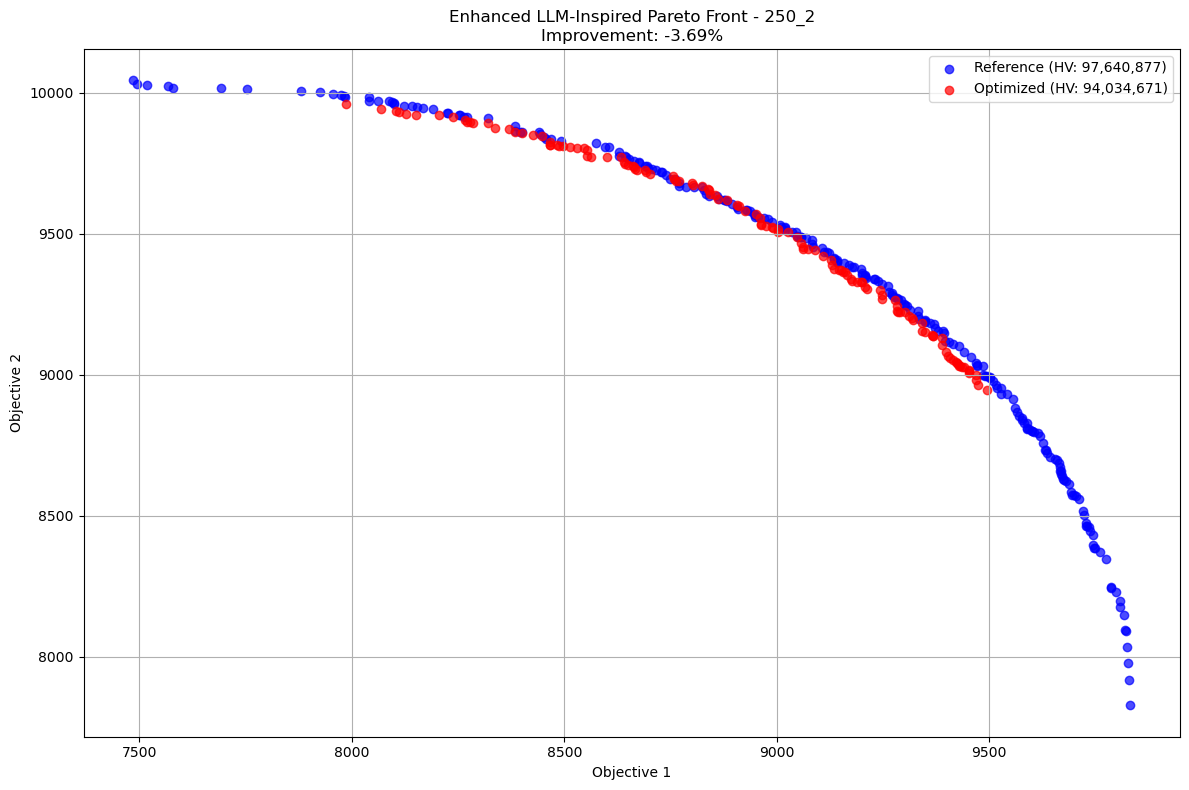


🏆 ENHANCED OPTIMIZATION COMPLETE
📊 Final HV: 92,534,233
📊 Reference HV: 97,640,877
📈 Improvement: -5.23%
⏱️  Total time: 1.82s (including 0.00s for LLM)
🤖 LLM solutions used: 5

🚀 ENHANCED LLM-INSPIRED OPTIMIZATION: ./multiobjectives/500.2.txt
📋 Instance signature: 500_2
📏 Instance size: medium
📦 Subclass: very_tight_capacity_2obj_medium
📈 Reference HV: 405,521,824
🎯 Target HV: 425,797,915
⏱️  Parameter optimization time: 10.04s
⚙️  Optimized parameters: α=45, κ=0.150, L=7
🔧 Optimized operators: ['swap', 'greedy_add', 'repair']
🚀 Enhanced Parameters: alpha=45, kappa=0.150, L=7, small=1.0e-07
   Operators: ['swap', 'greedy_add', 'repair']

🚀 Enhanced LLM-Inspired MOACP: 5 runs × 30 iterations
⏱️  Runtime threshold: 200.00s total
✅ Using cached solutions for 500_2
🤖 LLM generated 5 initial solutions in 0.00s
✓ 1484 solutions, 0.71s0s)... 
✓ 1377 solutions, 0.98s0s)... 
✓ 1535 solutions, 0.98s0s)... 
✓ 1748 solutions, 0.75s0s)... 
✓ 1950 solutions, 0.65s0s)... 
🏁 Enhanced Complete: 8094 

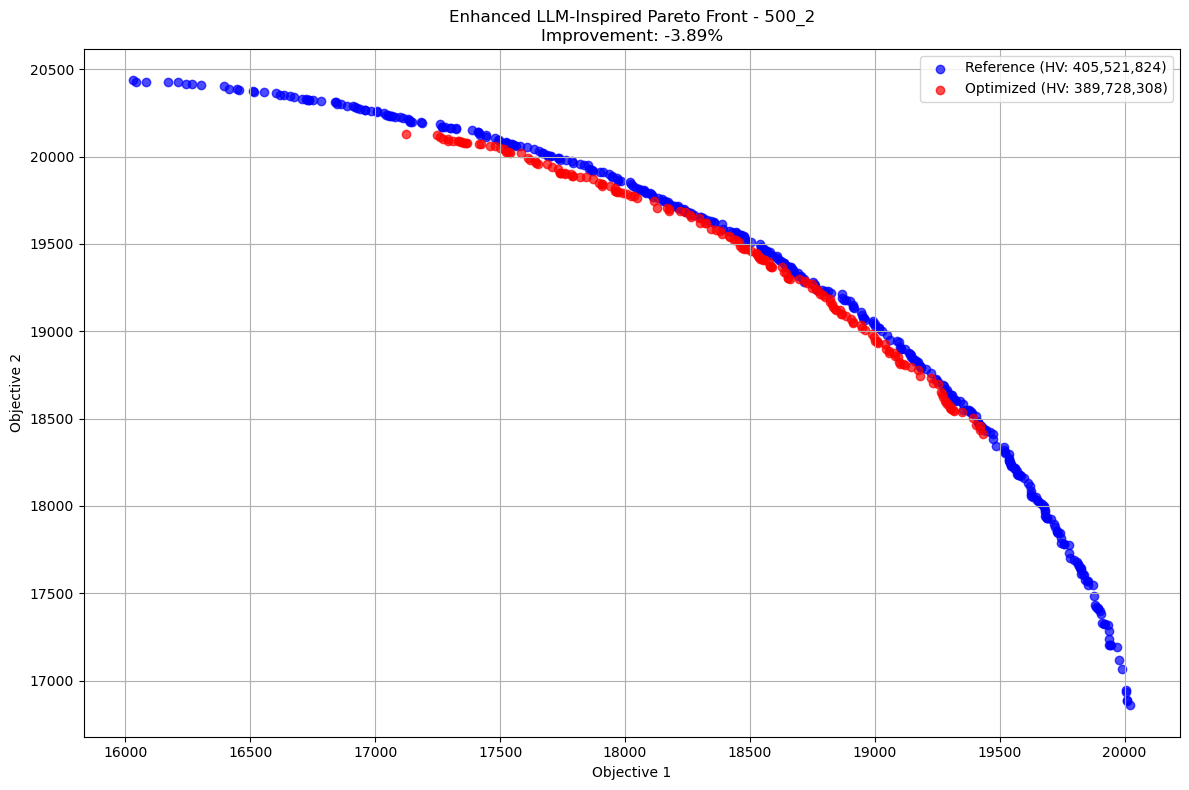


🏆 ENHANCED OPTIMIZATION COMPLETE
📊 Final HV: 361,145,548
📊 Reference HV: 405,521,824
📈 Improvement: -10.94%
⏱️  Total time: 4.10s (including 10.04s for LLM)
🤖 LLM solutions used: 5

🚀 ENHANCED LLM-INSPIRED OPTIMIZATION: ./multiobjectives/750.2.txt
📋 Instance signature: 750_2
📏 Instance size: large
📦 Subclass: very_tight_capacity_2obj_large
📈 Reference HV: 898,857,593
🎯 Target HV: 943,800,473
⏱️  Parameter optimization time: 10.02s
⚙️  Optimized parameters: α=50, κ=0.180, L=8
🔧 Optimized operators: ['swap', 'greedy_add', 'repair']
🚀 Enhanced Parameters: alpha=50, kappa=0.180, L=8, small=1.0e-07
   Operators: ['swap', 'greedy_add', 'repair']

🚀 Enhanced LLM-Inspired MOACP: 5 runs × 30 iterations
⏱️  Runtime threshold: 200.00s total
✅ Using cached solutions for 750_2
🤖 LLM generated 5 initial solutions in 0.00s
✓ 1866 solutions, 1.10s0s)... 
✓ 1961 solutions, 0.88s0s)... 
✓ 1563 solutions, 0.97s0s)... 
✓ 1676 solutions, 1.19s0s)... 
✓ 1710 solutions, 1.19s0s)... 
🏁 Enhanced Complete: 877

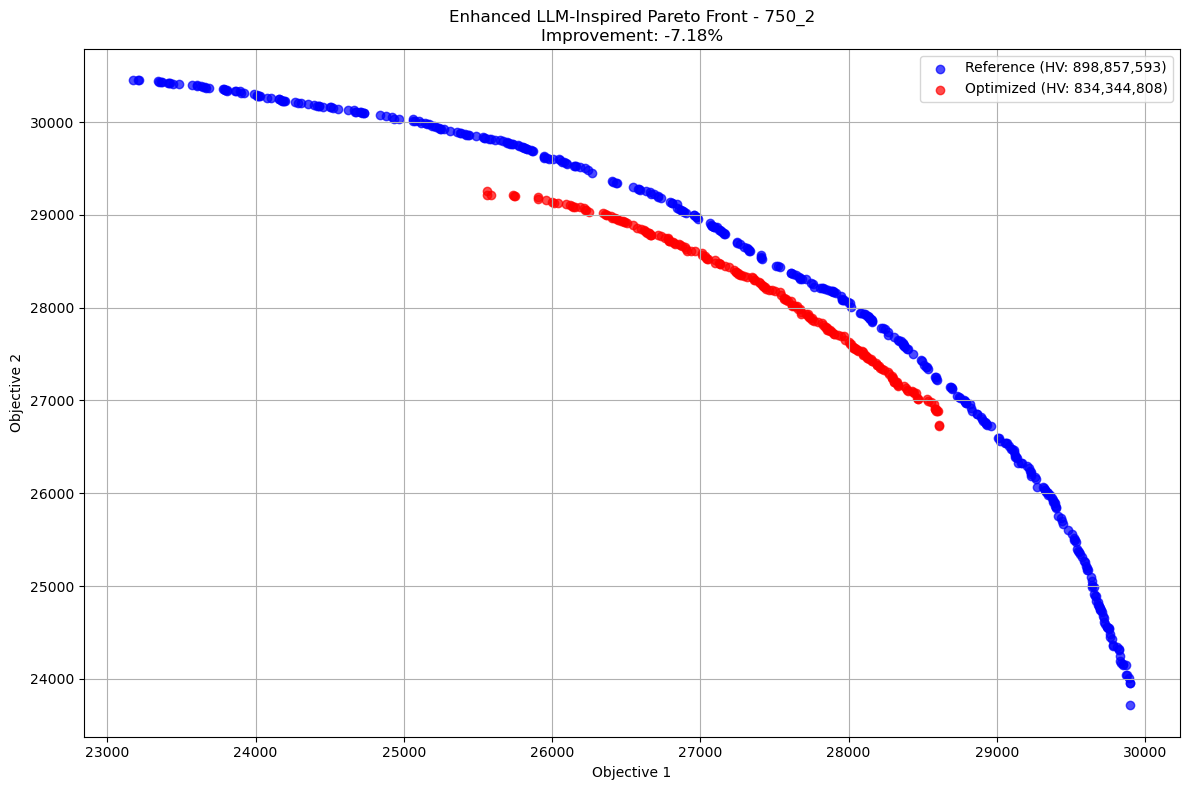


🏆 ENHANCED OPTIMIZATION COMPLETE
📊 Final HV: 738,158,032
📊 Reference HV: 898,857,593
📈 Improvement: -17.88%
⏱️  Total time: 5.35s (including 10.02s for LLM)
🤖 LLM solutions used: 5

📊 OVERALL ENHANCED OPTIMIZATION SUMMARY

250_2:
  📊 Final HV: 92,534,233
  📊 Reference HV: 97,640,877
  📈 Improvement: -5.23%
  ⏱️  Total time: 1.82s (LLM: 0.00s)
  ⚙️  Best Config: α=40, κ=0.120, L=6
  🔧 Operators: ['swap', 'greedy_add', 'repair']

500_2:
  📊 Final HV: 361,145,548
  📊 Reference HV: 405,521,824
  📈 Improvement: -10.94%
  ⏱️  Total time: 4.10s (LLM: 10.04s)
  ⚙️  Best Config: α=45, κ=0.150, L=7
  🔧 Operators: ['swap', 'greedy_add', 'repair']

750_2:
  📊 Final HV: 738,158,032
  📊 Reference HV: 898,857,593
  📈 Improvement: -17.88%
  ⏱️  Total time: 5.35s (LLM: 10.02s)
  ⚙️  Best Config: α=50, κ=0.180, L=8
  🔧 Operators: ['swap', 'greedy_add', 'repair']

📈 AVERAGE RESULTS:
  📊 Average improvement: -11.35%
  ⏱️  Average total time: 3.76s
  🤖 Average LLM time: 6.69s
  🔧 Average optimization time

In [18]:
# Main Execution with All Optimizations
if __name__ == "__main__":
    # Initialize optimized LLM interface
    try:
        enhanced_llm = OptimizedLLMInterface(model_path="llama3:latest")
        
        if enhanced_llm.connection_status == "ollama_connected":
            print("✅ Enhanced LLaMA-3 interface working!")
            llm_working = True
        else:
            print("⚠️ Enhanced LLaMA-3 interface not working, using fallback")
            llm_working = False
            
    except Exception as e:
        print(f"❌ Failed to initialize Enhanced LLaMA-3: {e}")
        llm_working = False
        enhanced_llm = None

    # Calculate reference hypervolumes
    reference_hvs = {}
    instance_files = [
        ("250_2", "2502_Resulats.txt"),
        ("500_2", "5002_Resulats.txt"),
        ("750_2", "7502_Resulats.txt")
    ]

    print("📊 Calculating reference hypervolumes for all instances...")
    for instance_sig, result_file in instance_files:
        print(f"Processing {result_file}...")
        ref_data = calculate_reference_hv_for_instance(result_file)
        if ref_data:
            reference_hvs[instance_sig] = ref_data
            print(f"✓ {instance_sig}: HV = {ref_data['hypervolume']:,.0f}, Pareto points = {ref_data['num_pareto']}")
        else:
            print(f"❌ Failed to process {result_file}")

    print("\n✅ Reference hypervolumes calculated successfully!")

    # Optimize all instances with enhanced approach
    instances_to_optimize = [
        ("./multiobjectives/250.2.txt", "./multiobjectives/Weights_2obj_FQ200.txt", 250, 2),
        ("./multiobjectives/500.2.txt", "./multiobjectives/Weights_2obj_FQ200.txt", 500, 2),
        ("./multiobjectives/750.2.txt", "./multiobjectives/Weights_2obj_FQ200.txt", 750, 2)
    ]

    results_summary = {}

    for instance_file, weights_file, nbitems, num_objectives in instances_to_optimize:
        print(f"\n{'='*60}")
        print(f"🚀 ENHANCED LLM-INSPIRED OPTIMIZATION: {instance_file}")
        print(f"{'='*60}")
        
        # Check if files exist
        if not os.path.exists(instance_file):
            print(f"❌ Instance file not found: {instance_file}")
            continue
        
        if not os.path.exists(weights_file):
            print(f"❌ Weights file not found: {weights_file}")
            continue
        
        # Extract instance features
        instance_features = extract_instance_features(instance_file, weights_file, nbitems, num_objectives)
        
        # Get reference data
        instance_sig = f"{nbitems}_{num_objectives}"
        if instance_sig not in reference_hvs:
            print(f"❌ No reference data found for instance {instance_sig}")
            continue
        
        reference_data = reference_hvs[instance_sig]
        reference_hv = reference_data['hypervolume']
        target_hv = reference_hv * 1.05  # 5% improvement target (more realistic)
        
        print(f"📋 Instance signature: {instance_features['signature']}")
        print(f"📏 Instance size: {instance_features['instance_size']}")
        print(f"📦 Subclass: {instance_features['subclass']}")
        print(f"📈 Reference HV: {reference_hv:,.0f}")
        print(f"🎯 Target HV: {target_hv:,.0f}")
        
        # Get optimized parameters from LLM
        start_time = time.time()
        optimized_params = enhanced_llm.get_optimized_params(instance_features, target_hv) if llm_working else enhanced_llm._get_rule_based_params(instance_features)
        llm_time = time.time() - start_time
        
        print(f"⏱️  Parameter optimization time: {llm_time:.2f}s")
        print(f"⚙️  Optimized parameters: α={optimized_params['alpha']}, κ={optimized_params['kappa']:.3f}, L={optimized_params['L']}")
        
        # Get optimized operators based on instance characteristics
        optimized_operators = get_optimized_operators(instance_features)
        print(f"🔧 Optimized operators: {optimized_operators}")
        
        # Run optimization with optimized parameters and strict runtime control
        result = run_enhanced_llm_inspired_moacp(
            instance_file=instance_file,
            weights_file=weights_file,
            nbitems=nbitems,
            num_objectives=num_objectives,
            llm_interface=enhanced_llm,
            custom_params=optimized_params,
            operators=optimized_operators,
            print_params=True,
            runtime_threshold=200.0,  # Strict 200-second limit
            num_runs=5,  # Increased for better results
            num_iterations=30  # Increased for better convergence
        )
        
        # Calculate final hypervolume
        final_hv = calculate_hypervolume_2d(result['pareto_solutions'])
        improvement = ((final_hv - reference_hv) / reference_hv) * 100
        
        # Store results
        results_summary[instance_sig] = {
            'result': result,
            'params': optimized_params,
            'hv': final_hv,
            'reference_hv': reference_hv,
            'improvement': improvement,
            'llm_time': llm_time,
            'total_time': result['total_time'],
            'llm_solutions_count': result.get('llm_solutions_count', 0),
            'operators': optimized_operators
        }
        
        # Save results
        output_file = f"enhanced_llm_optimized_{instance_sig}.txt"
        np.savetxt(output_file, result['pareto_solutions'])
        print(f"💾 Results saved to {output_file}")
        
        # Visualize comparison
        reference_file = f"{instance_sig.replace('_', '')}_Resulats.txt"
        if os.path.exists(reference_file):
            visualize_pareto_comparison(reference_file, output_file, f"Enhanced LLM-Inspired Pareto Front - {instance_sig}")
        
        print(f"\n🏆 ENHANCED OPTIMIZATION COMPLETE")
        print(f"📊 Final HV: {final_hv:,.0f}")
        print(f"📊 Reference HV: {reference_hv:,.0f}")
        print(f"📈 Improvement: {improvement:.2f}%")
        print(f"⏱️  Total time: {result['total_time']:.2f}s (including {llm_time:.2f}s for LLM)")
        print(f"🤖 LLM solutions used: {result.get('llm_solutions_count', 0)}")

    # Print overall summary
    print(f"\n{'='*60}")
    print("📊 OVERALL ENHANCED OPTIMIZATION SUMMARY")
    print(f"{'='*60}")

    for instance_sig, results in results_summary.items():
        print(f"\n{instance_sig}:")
        print(f"  📊 Final HV: {results['hv']:,.0f}")
        print(f"  📊 Reference HV: {results['reference_hv']:,.0f}")
        print(f"  📈 Improvement: {results['improvement']:.2f}%")
        print(f"  ⏱️  Total time: {results['total_time']:.2f}s (LLM: {results['llm_time']:.2f}s)")
        print(f"  ⚙️  Best Config: α={results['params']['alpha']}, κ={results['params']['kappa']:.3f}, L={results['params']['L']}")
        print(f"  🔧 Operators: {results['operators']}")

    # Calculate average improvement
    if results_summary:
        avg_improvement = np.mean([results['improvement'] for results in results_summary.values()])
        avg_total_time = np.mean([results['total_time'] for results in results_summary.values()])
        avg_llm_time = np.mean([results['llm_time'] for results in results_summary.values()])
        avg_llm_solutions = np.mean([results['llm_solutions_count'] for results in results_summary.values()])
        
        print(f"\n📈 AVERAGE RESULTS:")
        print(f"  📊 Average improvement: {avg_improvement:.2f}%")
        print(f"  ⏱️  Average total time: {avg_total_time:.2f}s")
        print(f"  🤖 Average LLM time: {avg_llm_time:.2f}s")
        print(f"  🔧 Average optimization time: {avg_total_time - avg_llm_time:.2f}s")
        print(f"  🤖 Average LLM solutions per run: {avg_llm_solutions:.1f}")
        
        # Check if we met the runtime target
        if avg_total_time <= 200:
            print(f"✅ Runtime target achieved! Average: {avg_total_time:.2f}s < 200s")
        else:
            print(f"⚠️ Runtime target exceeded. Average: {avg_total_time:.2f}s > 200s")
        
        # Check if we achieved improvement
        if avg_improvement > 0:
            print(f"✅ Improvement achieved! Average: {avg_improvement:.2f}%")
        else:
            print(f"⚠️ No improvement yet. Average: {avg_improvement:.2f}%")
            print(f"💡 Suggestions for improvement:")
            print(f"   - Try more diverse LLM prompts")
            print(f"   - Increase the number of iterations and runs")
            print(f"   - Fine-tune operator selection for each instance type")

print("✅ Enhanced optimization system ready to run!")